# Часть 1

## Загрузка датасета

In [280]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [281]:
df = pd.read_csv('data_ab.csv')
df.head(3)

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


## EDA

**1. Проверим датасет на наличие пропусков.**

In [283]:
for colum_name in df.columns:
    print(f'В столбце: "{colum_name}", кол-во пропусков = {df[colum_name].isnull().sum()}')

В столбце: "user_id", кол-во пропусков = 0
В столбце: "timestamp", кол-во пропусков = 0
В столбце: "group", кол-во пропусков = 0
В столбце: "landing_page", кол-во пропусков = 0
В столбце: "converted", кол-во пропусков = 0


В датасете нет пропущенных значений

**2. Теперь проверим уникальность user_id**

В теории, каждый id должен быть уникальным, значит их кол-во должно совпадать с кол-вом строк (или можно просто посмотреть на дубликаты по полю)

In [284]:
user_id_dupl = df['user_id'].duplicated().sum()
user_id_dupl

3894

In [285]:
df['user_id'].nunique() == len(df['user_id'])

False

Вывод: найдены дубликаты по полю 'user_id'. 

Посмотрим на них. Сохраним user_id из дубликатов и выведем отсорированный датасет по тому же полю.

In [286]:
dupl_id = df[df['user_id'].duplicated()]['user_id']

dupl_id_analysis = df[df['user_id'].isin(dupl_id)].sort_values('user_id')
dupl_id_analysis

,user_id,timestamp,group,landing_page,converted
230259,630052,2025-01-17 01:16:05.208766,treatment,new_page,0
213114,630052,2025-01-07 12:25:54.089486,treatment,old_page,1
22513,630126,2025-01-14 13:35:54.778695,treatment,old_page,0
251762,630126,2025-01-19 17:16:00.280440,treatment,new_page,0
183371,630137,2025-01-20 02:08:49.893878,control,old_page,0
...,...,...,...,...,...
142354,945703,2025-01-08 19:40:51.169351,control,new_page,0
186960,945797,2025-01-13 17:23:21.750962,control,old_page,0
40370,945797,2025-01-11 03:04:49.433736,control,new_page,1
165143,945971,2025-01-16 10:09:18.383183,control,old_page,0


Посмотрим на группы, к которым относится пользователи с одинаковыми user_id - совпадают или не совпадают группы (treatment/control).

In [287]:
similar_group = dupl_id_analysis.groupby('user_id')['group'].nunique() == 1
similar_group

user_id
630052     True
630126     True
630137     True
630320    False
630471     True
          ...  
945627    False
945645     True
945703     True
945797     True
945971     True
Name: group, Length: 3894, dtype: bool

In [288]:
print(f'Число записей, где группы совпали по id: {similar_group.sum()}')
print(f'Число записей, где пользователи в разных группах по id: {(~similar_group).sum()}')

Число записей, где группы совпали по id: 1999
Число записей, где пользователи в разных группах по id: 1895


In [289]:
user_in_2_gropus_id = similar_group[~similar_group].index
df[df['user_id'].isin(user_in_2_gropus_id)].sort_values('user_id')

,user_id,timestamp,group,landing_page,converted
207211,630320,2025-01-07 18:02:43.626318,control,old_page,0
255753,630320,2025-01-12 05:27:37.181803,treatment,old_page,0
39852,630805,2025-01-22 12:01:15.144329,control,old_page,0
73599,630805,2025-01-12 20:45:39.012189,treatment,old_page,0
213377,630871,2025-01-08 14:00:05.181612,control,old_page,0
...,...,...,...,...,...
257763,945369,2025-01-15 11:08:09.106160,control,old_page,0
183169,945387,2025-01-03 01:12:35.747597,treatment,new_page,0
275158,945387,2025-01-20 02:12:45.553852,control,new_page,0
49419,945627,2025-01-06 00:03:20.474879,control,new_page,1


Вывод: есть 1895 пользователей, которым показывает одновременно новая и старая версия сайта. Данная ситуация исказит результаты будущего A/B теста, поэтому нужно это исправить.

Командой было решено удалить тех, кому показывается обе версии сайта (1895 уникальных user_id, следовательно удалим в 2 раза больше строк).

In [290]:
befor_delete = len(df)
print(f'Строк до удаления: {befor_delete}')

df = df[~df['user_id'].isin(user_in_2_gropus_id)]

after_delete = len(df)
print(f'Строк после удаления: {after_delete}, удалено: {befor_delete - after_delete}')

Строк до удаления: 294478
Строк после удаления: 290688, удалено: 3790


Осталось решить проблему дубликатов, которые попали в одну группу.

*Глобально есть 5 вариантов:*
1. оставь 1 хронологическую запись (по полю 'timestamp');
2. оставь 2 хронологическую запись (по полю 'timestamp');
3. оставить тех, кто совершил целевое действие 'control' = 1;
4. оставить тех, кто не совершил целевое действие 'control' = 0;
5. удалить все записи c дубликатами (1999 * 2 = 3998 строк).

Для поставленной задачи, наиболее оптимальным является вариант номер 1, потому что будущий A/B-тест должен показать влияние новой страницы при первом обращении (тогда существует меньше искажений - тех факторов, которые могли бы повлиять на пользователя при совершении/не совершении целевого действия).

Ну и как приятный бонус - у нас будет больше данных, чем если бы мы просто удалили все строки с дубликатами.

In [291]:
befor_delete = len(df)
print(f'Строк до удаления: {befor_delete}')

df = df.sort_values('timestamp').drop_duplicates(
    subset='user_id',
    keep='first'
)

after_delete = len(df)
print(f'Строк после удаления: {after_delete}, удалено: {befor_delete - after_delete}')

Строк до удаления: 290688
Строк после удаления: 288689, удалено: 1999


In [292]:
user_id_dupl = df['user_id'].duplicated().sum()
user_id_dupl

0

Вывод: очистили датасет от дубликатов по полю 'user_id'.

**3. Анализ признака 'timestamp'**

Первое на что стоит обратить внимание на то, как датасет распределен во времени. Если данные брались только под A/B-тест, то границы временных значений должны совпадать для обеих групп.

In [293]:
start_exp = df['timestamp'].min()
end_exp = df['timestamp'].max()

print(f'Минимальная запись: {start_exp}')
print(f'Максимальная запись: {end_exp}')

Минимальная запись: 2025-01-02 13:42:05.378582
Максимальная запись: 2025-01-24 13:41:54.460509


Вывод: датасет содержит данные за 23 дня наблюдей. Согласно с допушением выше - 23 дня это срок проводимого эксперимента.

*Теперь посмотрим на первое и последнее появление записей, в зависимости от группы пользователя.*

In [294]:
df.groupby('group')['timestamp'].min()

group
control      2025-01-02 13:42:15.234051
treatment    2025-01-02 13:42:05.378582
Name: timestamp, dtype: object

In [295]:
df.groupby('group')['timestamp'].max()

group
control      2025-01-24 13:41:54.460509
treatment    2025-01-24 13:41:44.097174
Name: timestamp, dtype: object

Вывод: начало и конец эксперимента для обеих групп различается несущественно.

*Создадим визуализацию для оценки равномерности потока новым пользователей*

За основу приведем 'timestamp' к формату дней (через dt.date) и будем смотреть кол-во пользователей 'user_id', поскольку теперь оно содержит только уникальные значения.

In [296]:
df['timestamp'].dtype

dtype('O')

Тип 'timestamp' - строка, чтобы удобно работать с этим приведем его к datetime

In [297]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [298]:
df['timestamp'].dtype

dtype('<M8[ns]')

Сделаем группировку

In [299]:
amount_of_users_per_day = df.groupby(df['timestamp'].dt.date)['user_id'].count()
amount_of_users_per_day

timestamp
2025-01-02     5715
2025-01-03    13211
2025-01-04    13090
2025-01-05    12913
2025-01-06    13327
2025-01-07    13161
2025-01-08    13356
2025-01-09    13196
2025-01-10    13290
2025-01-11    13303
2025-01-12    13086
2025-01-13    12977
2025-01-14    13058
2025-01-15    13154
2025-01-16    13019
2025-01-17    13036
2025-01-18    12965
2025-01-19    13003
2025-01-20    13080
2025-01-21    13158
2025-01-22    13075
2025-01-23    13170
2025-01-24     7346
Name: user_id, dtype: int64

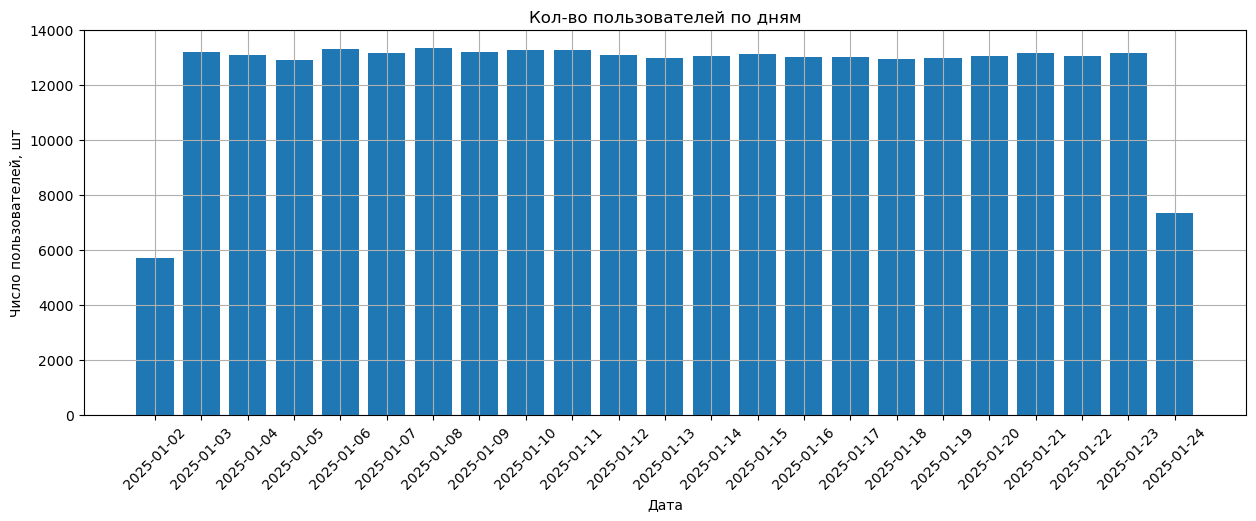

In [300]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(
    amount_of_users_per_day.index,
    amount_of_users_per_day.values
)

ax.set_xticks(amount_of_users_per_day.index)
plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

Вывод: приток пользователей во времени равномерен и стабильно выше 12 тыс/день, кроме первого и последнего дней (02.01.2025, 24.01.2025).

Теперь можем добавь разбивку по группе пользователей.

In [301]:
amount_users_grouped_day = df.groupby([df['timestamp'].dt.date, 'group'])['user_id'].count().reset_index()
amount_users_grouped_day

,timestamp,group,user_id
0,2025-01-02,control,2854
1,2025-01-02,treatment,2861
2,2025-01-03,control,6593
3,2025-01-03,treatment,6618
4,2025-01-04,control,6561
5,2025-01-04,treatment,6529
6,2025-01-05,control,6417
7,2025-01-05,treatment,6496
8,2025-01-06,control,6595
9,2025-01-06,treatment,6732


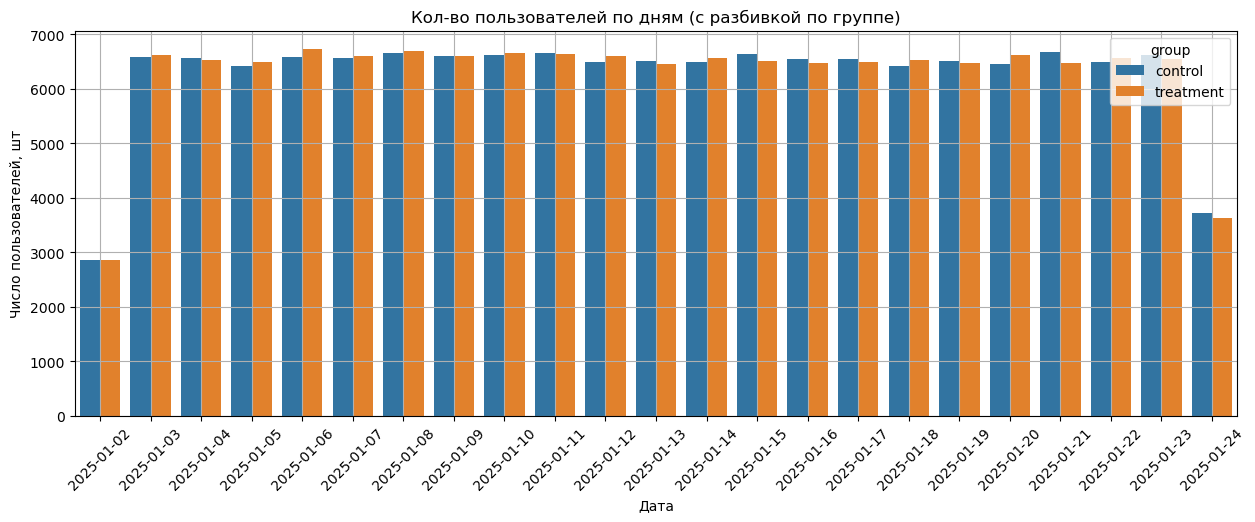

In [302]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data = amount_users_grouped_day,
    x = 'timestamp',
    y = 'user_id',
    hue = 'group',
    ax = ax
)

plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по дням (c разбивкой по группе)')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

Вывод: группы пользователей распределены равномерно, относитлеьно друг друга на определенную дату.

Остается посмотреть на распределение пользователей по часам, возможно получится увидеть пиковые часы или наоборот - просадки активности.

In [303]:
amount_of_users_per_hour = df.groupby(df['timestamp'].dt.hour)['user_id'].count()
amount_of_users_per_hour

timestamp
0     11844
1     12170
2     11980
3     12052
4     11949
5     12174
6     11999
7     12083
8     12033
9     11883
10    12045
11    12062
12    12032
13    11919
14    12151
15    11813
16    12202
17    12118
18    12045
19    12057
20    11980
21    11978
22    12098
23    12022
Name: user_id, dtype: int64

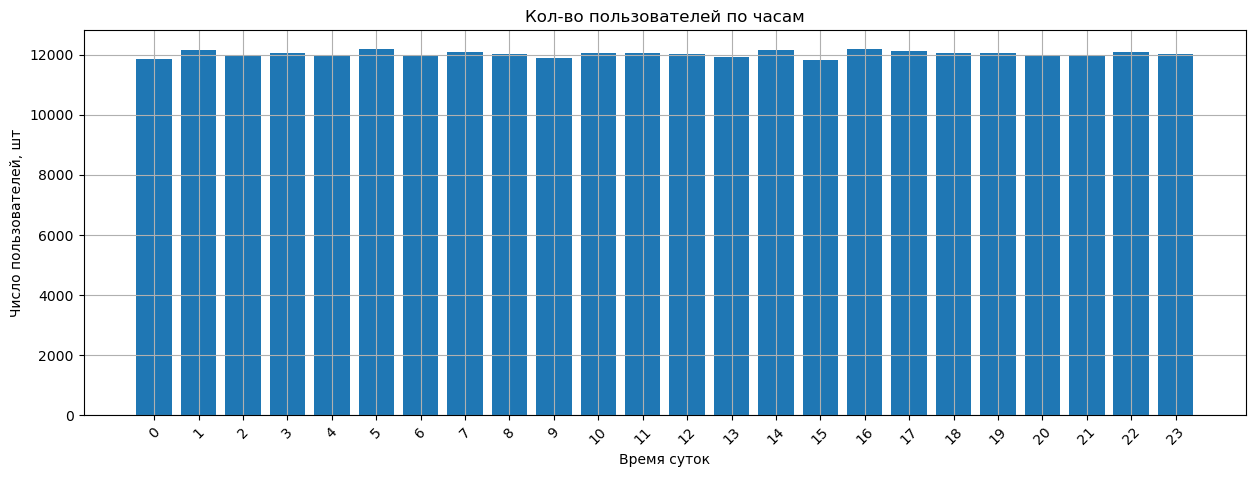

In [304]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(
    amount_of_users_per_hour.index,
    amount_of_users_per_hour.values
)

ax.set_xticks(amount_of_users_per_hour.index)
plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по часам')
ax.set_xlabel('Время суток')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

In [305]:
amount_users_grouped_hour =  df.groupby([df['timestamp'].dt.hour, 'group'])['user_id'].count().reset_index()
amount_users_grouped_hour

,timestamp,group,user_id
0,0,control,5872
1,0,treatment,5972
2,1,control,6161
3,1,treatment,6009
4,2,control,6017
5,2,treatment,5963
6,3,control,5860
7,3,treatment,6192
8,4,control,6023
9,4,treatment,5926


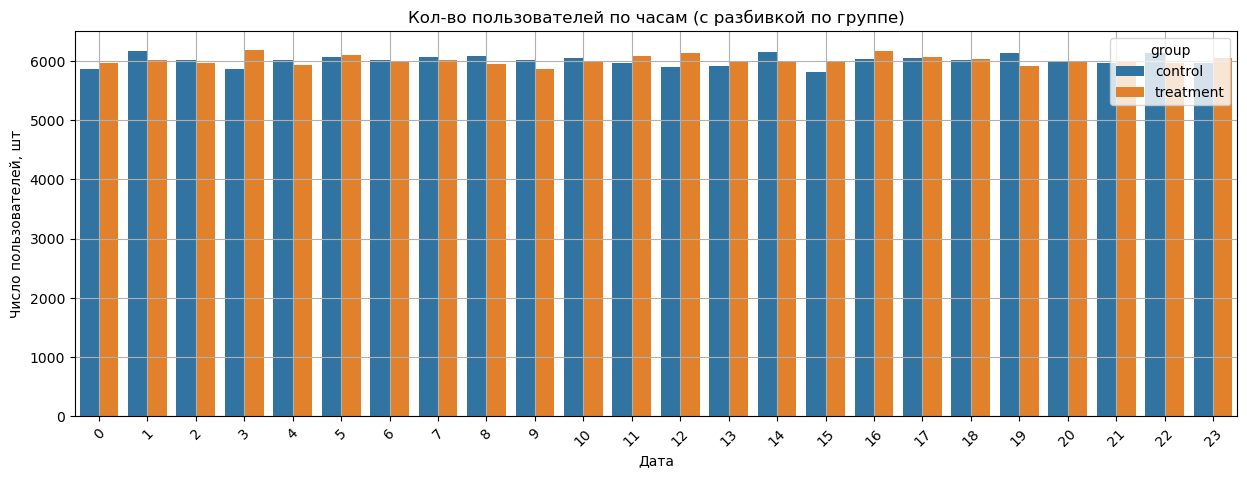

In [306]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data = amount_users_grouped_hour,
    x = 'timestamp',
    y = 'user_id',
    hue = 'group',
    ax = ax
)

plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по часам (c разбивкой по группе)')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

Вывод: данные по активности пользователей, в зависимости от времени суток, отсутствуют.

In [307]:
amount_of_users_per_day

timestamp
2025-01-02     5715
2025-01-03    13211
2025-01-04    13090
2025-01-05    12913
2025-01-06    13327
2025-01-07    13161
2025-01-08    13356
2025-01-09    13196
2025-01-10    13290
2025-01-11    13303
2025-01-12    13086
2025-01-13    12977
2025-01-14    13058
2025-01-15    13154
2025-01-16    13019
2025-01-17    13036
2025-01-18    12965
2025-01-19    13003
2025-01-20    13080
2025-01-21    13158
2025-01-22    13075
2025-01-23    13170
2025-01-24     7346
Name: user_id, dtype: int64

In [308]:
first_day = int(amount_of_users_per_day.iloc[0])
second_day = int(amount_of_users_per_day.iloc[1])

print(first_day, second_day)

print(1 - (first_day / second_day), '-----', (second_day - first_day))

5715 13211
0.567405949587465 ----- 7496


*Предположения относительно роста кол-во наблюдений в период 03.01.2025-23.01.2025*

Учитывая, что с 03.01.2025 было значитеьно больше пользователей (и их кол-во сохранялось до 23.01.2025), можно предположить, что в этот период проводилась акция, были спец. условия или что-то еще, что обеспечило прирост пользователей на 7496 (+56%).

**4. Анализ признака 'group'**

Распределение пользователей по группам (кол-во 'user_id' в каждой группе).

In [309]:
amount_of_users_in_groups = df.groupby('group')['user_id'].count()
amount_of_users_in_groups

group
control      144300
treatment    144389
Name: user_id, dtype: int64

In [310]:
control_users = amount_of_users_in_groups['control']
treatment_users = amount_of_users_in_groups['treatment']

print(f'Абсолютная разница между группами: {abs(control_users - treatment_users)} пользователей или {np.round(((treatment_users / control_users) - 1) * 100, 2)}%')

Абсолютная разница между группами: 89 пользователей или 0.06%


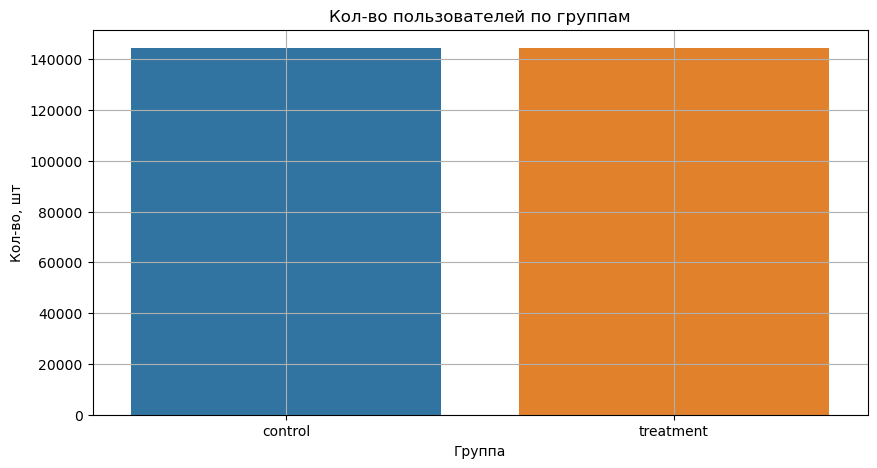

In [311]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = amount_of_users_in_groups.index,
    y = amount_of_users_in_groups.values,
    ax = ax
)

ax.set_title('Кол-во пользователей по группам')
ax.set_xlabel('Группа')
ax.set_ylabel('Кол-во, шт')

plt.grid()
plt.show()

Влияние распределения по группам на конверсию (признак: 'converted').

In [312]:
converted_by_groups = df.groupby('group')['converted'].mean()
converted_by_groups 

group
control      0.120402
treatment    0.118769
Name: converted, dtype: float64

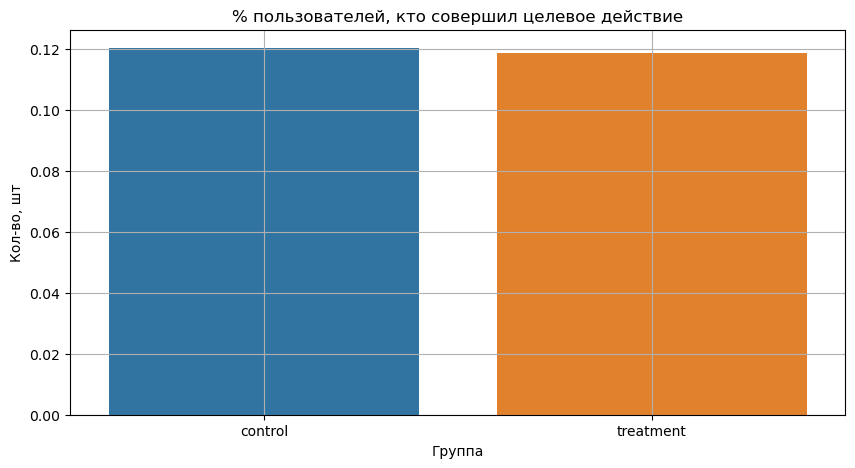

In [313]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = converted_by_groups.index,
    y = converted_by_groups.values,
    ax = ax
)

ax.set_title('% пользователей, кто совершил целевое действие')
ax.set_xlabel('Группа')
ax.set_ylabel('Кол-во, шт')

plt.grid()
plt.show()

Вывод: <НАПИСАТЬ>

**5. Работа с признаком landing_page**

По задумке (сказано в задание к ГП), 
- пользователям из группы treatment должна показываться новая версия сайта, то есть признак 'landing_page' = new_page
- пользователям из группы control должна показываться текущая версия сайта, то есть признак 'landing_page' = old_page

Проверим это. Используем удобный метод, который позволит создать сводную таблицу между двумя выбранными признаками:
- https://sky.pro/wiki/analytics/analiz-dannyh-s-pdcrosstab-v-python-sozdaem-svodnye-tablicy/
- https://www.geeksforgeeks.org/data-analysis/what-is-cross-tabulation-and-how-does-it-organize-data-in-a-table/

In [314]:
cross_analysis = pd.crosstab(
    df['group'],
    df['landing_page']
)
cross_analysis

landing_page,new_page,old_page
group,,
control,482,143818
treatment,143888,501


In [315]:
befor_delete = len(df)
print(f'Строк до удаления: {befor_delete}')

df = df[
    ((df['group'] == 'control') & (df['landing_page'] == 'old_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))
].reset_index(drop=True)


after_delete = len(df)
print(f'Строк после удаления: {after_delete}, удалено: {befor_delete - after_delete}')

Строк до удаления: 288689
Строк после удаления: 287706, удалено: 983


In [316]:
cross_analysis = pd.crosstab(
    df['group'],
    df['landing_page']
)
cross_analysis

landing_page,new_page,old_page
group,,
control,0,143818
treatment,143888,0


Вывод: были удалены записи, которые ошибочно попали не в ту категорию.

**Повторим результаты прошлых анализов: вдруг ошибочные записи портили резульаты прошлых EDA.**

Копипаст кода из 3 и 4 разделов

In [317]:
amount_of_users_per_day = df.groupby(df['timestamp'].dt.date)['user_id'].count()

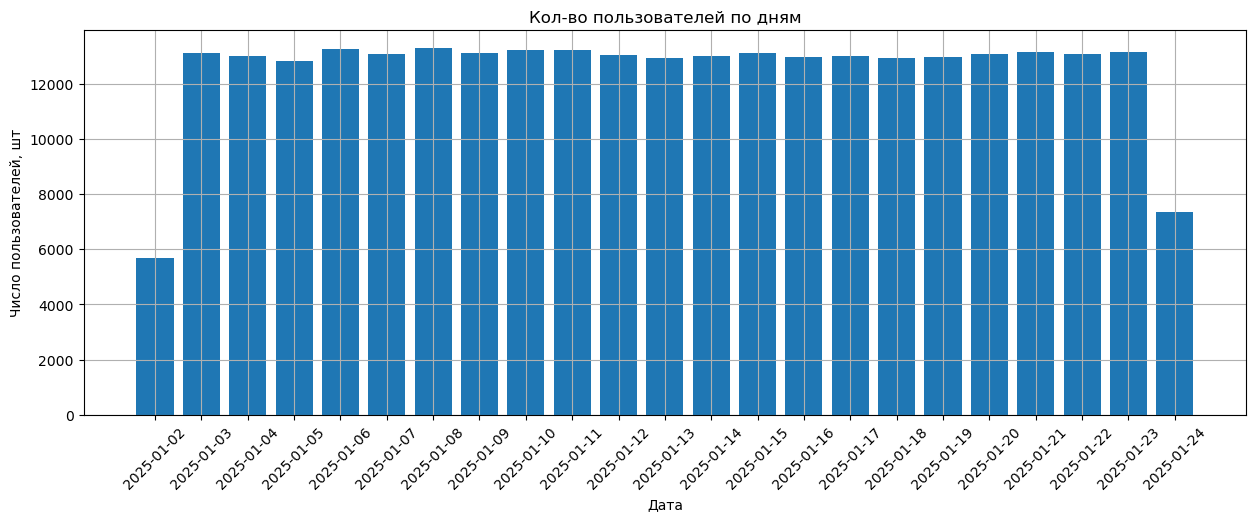

In [318]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(
    amount_of_users_per_day.index,
    amount_of_users_per_day.values
)

ax.set_xticks(amount_of_users_per_day.index)
plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

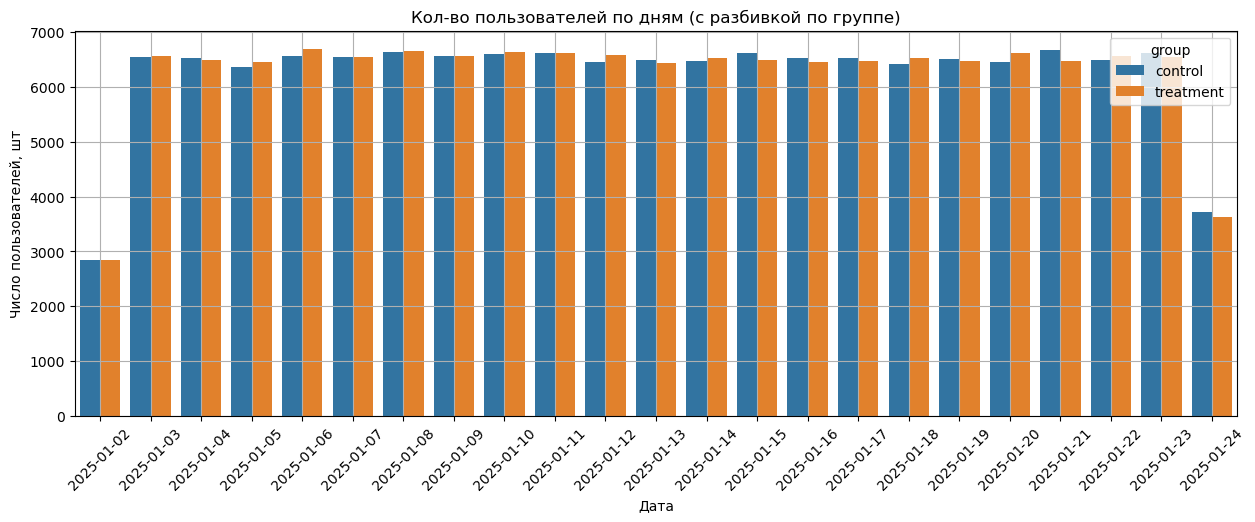

In [319]:
amount_users_grouped_day = df.groupby([df['timestamp'].dt.date, 'group'])['user_id'].count().reset_index()

fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data = amount_users_grouped_day,
    x = 'timestamp',
    y = 'user_id',
    hue = 'group',
    ax = ax
)

plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по дням (c разбивкой по группе)')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

In [320]:
amount_of_users_per_hour = df.groupby(df['timestamp'].dt.hour)['user_id'].count()

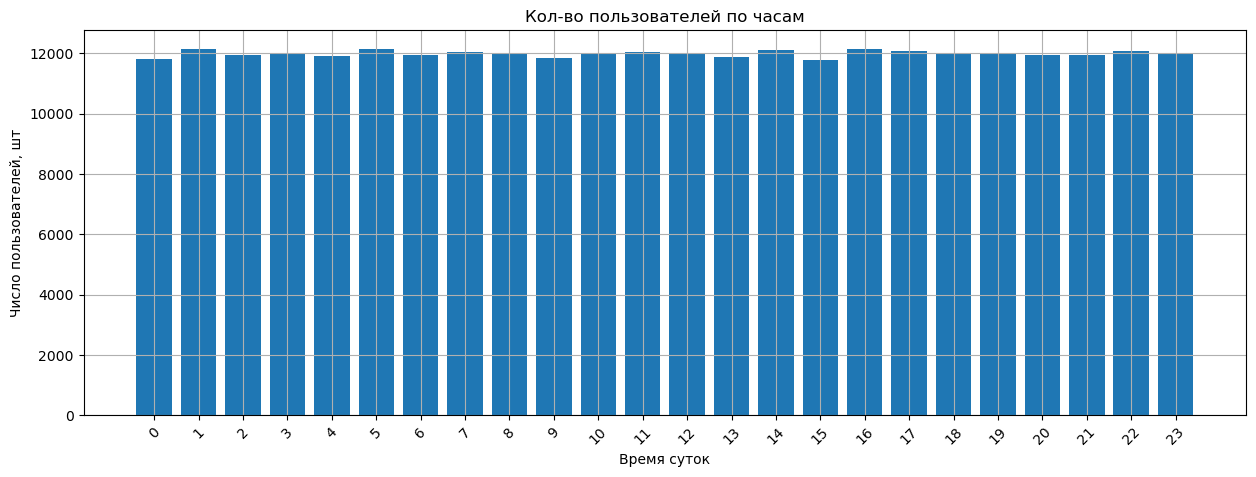

In [321]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.bar(
    amount_of_users_per_hour.index,
    amount_of_users_per_hour.values
)

ax.set_xticks(amount_of_users_per_hour.index)
plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по часам')
ax.set_xlabel('Время суток')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()

In [322]:
amount_users_grouped_hour =  df.groupby([df['timestamp'].dt.hour, 'group'])['user_id'].count().reset_index()

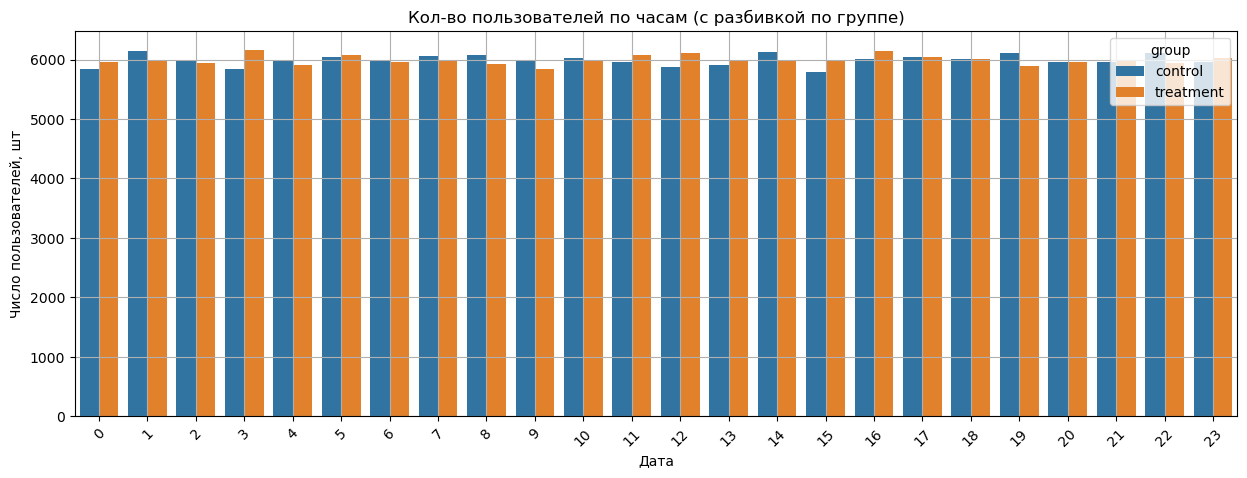

In [323]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.barplot(
    data = amount_users_grouped_hour,
    x = 'timestamp',
    y = 'user_id',
    hue = 'group',
    ax = ax
)

plt.xticks(rotation=45)

ax.set_title('Кол-во пользователей по часам (c разбивкой по группе)')
ax.set_xlabel('Дата')
ax.set_ylabel('Число пользователей, шт')

plt.grid()
plt.show()


In [324]:
amount_of_users_in_groups = df.groupby('group')['user_id'].count()
amount_of_users_in_groups

group
control      143818
treatment    143888
Name: user_id, dtype: int64

In [325]:
control_users = amount_of_users_in_groups['control']
treatment_users = amount_of_users_in_groups['treatment']

print(f'Абсолютная разница между группами: {abs(control_users - treatment_users)} пользователей или {np.round(((treatment_users / control_users) - 1) * 100, 2)}%')

Абсолютная разница между группами: 70 пользователей или 0.05%


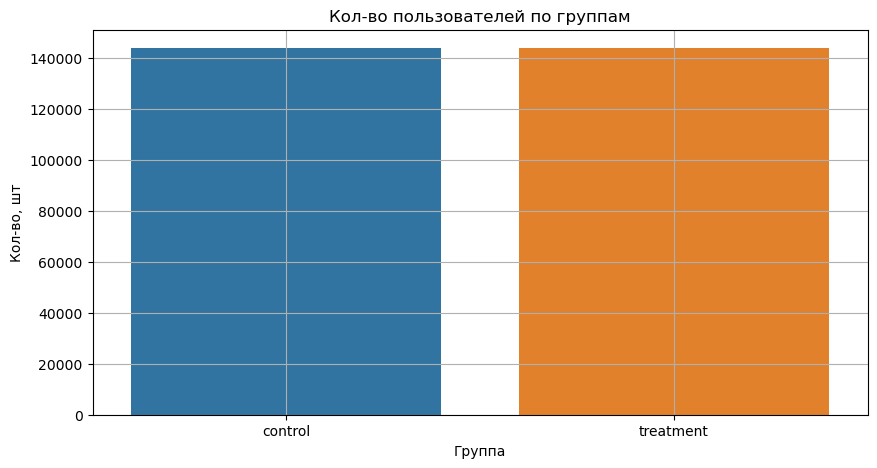

In [326]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = amount_of_users_in_groups.index,
    y = amount_of_users_in_groups.values,
    ax = ax
)

ax.set_title('Кол-во пользователей по группам')
ax.set_xlabel('Группа')
ax.set_ylabel('Кол-во, шт')

plt.grid()
plt.show()

In [327]:
converted_by_groups = df.groupby('group')['converted'].mean()
converted_by_groups

group
control      0.120354
treatment    0.118710
Name: converted, dtype: float64

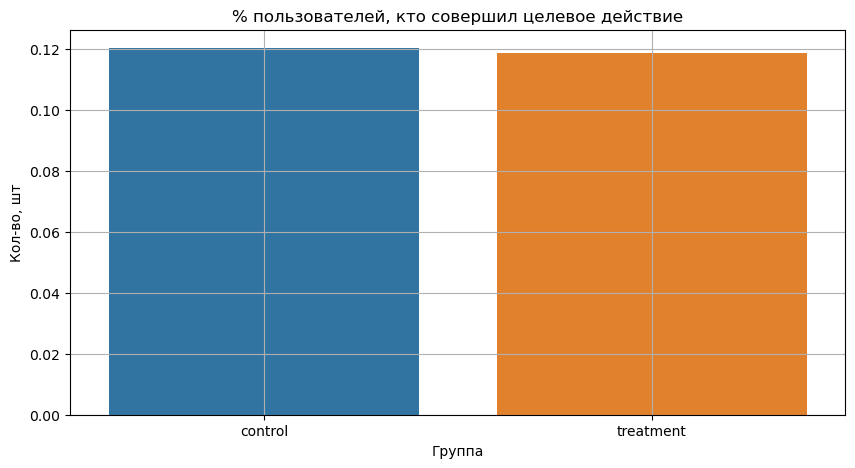

In [328]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = converted_by_groups.index,
    y = converted_by_groups.values,
    ax = ax
)

ax.set_title('% пользователей, кто совершил целевое действие')
ax.set_xlabel('Группа')
ax.set_ylabel('Кол-во, шт')

plt.grid()
plt.show()

Вывод: влияние ошибок было незначительно.

**6. Общий анализ признака 'converted'**

In [329]:
converted_analysis = df['converted'].value_counts()
converted_analysis

converted
0    253316
1     34390
Name: count, dtype: int64

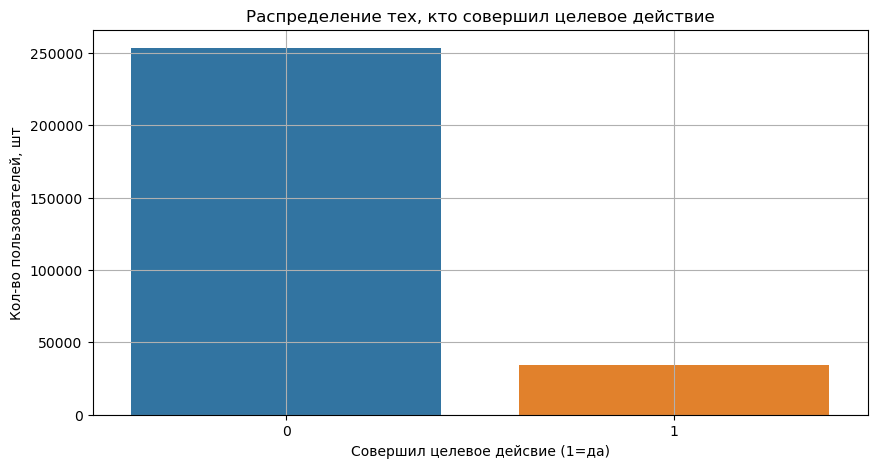

In [330]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x = converted_analysis.index,
    y = converted_analysis.values,
    ax = ax
)

ax.set_title('Распределение тех, кто совершил целевое действие')
ax.set_xlabel('Совершил целевое дейсвие (1=да)')
ax.set_ylabel('Кол-во пользователей, шт')

plt.grid()
plt.show()